# Correlation Analysis for Three-Tier HP Model

This notebook analyzes correlations between features in the three-tier HP model to identify:
1. Multicollinearity issues (high correlation between predictors)
2. Features that should be removed or restructured
3. Whether flying should move from Phase 3 to Phase 2
4. Why some Phase 3 features show positive HP contributions

## Key Questions
- Are Phase 2 features (AC, Attack, DPR, Save DC deviations) correlated with each other?
- Are Phase 3 features correlated with Phase 2 features?
- Does flying correlate with CR (supporting move to Phase 2)?
- Which features have high VIF scores indicating multicollinearity?

In [1]:
# pip install statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load Data

In [3]:
import os
os.listdir()

['.git',
 'notebooks',
 'model_data.json',
 'pickled_models',
 'IMPLEMENTATION_SUMMARY.md',
 'parse_monsters.py',
 'GITHUB_PAGES_SETUP.md',
 'condition_feature_engineering.py',
 'README_OLD.md',
 'requirements.txt',
 'monster-builder-v2',
 'CONTEXT.md',
 'test_owlbear_prediction.py',
 '.claude',
 '.gitignore',
 'README_CR_MODEL.md',
 'NOTEBOOK_EXECUTION_GUIDE.md',
 '.vscode',
 'monster-builder-app',
 'monsters_list.html',
 '.workspace_config',
 'test_owlbear_detailed.py',
 'run_correlation_analysis.py',
 'QUICKSTART.md',
 'constrained_condition_model.py',
 'PROJECT_STRUCTURE.md',
 'index.html',
 'running_commands.py',
 'data',
 'setup.sh',
 'predict_aarakocra.py',
 'run_three_tier_model.py',
 '.devcontainer',
 'README_MONSTERS.md',
 'README.md',
 '.venv']

In [4]:
# Load engineered features dataset
df = pd.read_csv('./data/engineered_features.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (382, 74)

Columns: ['Name', 'Type', 'Size', 'Challenge_Rating', 'cr_numeric', 'HP', 'actual_hp', 'AC', 'ac_value', 'hp_baseline', 'ac_baseline', 'attack_baseline', 'dpr_baseline', 'dc_baseline', 'highest_attack_bonus', 'highest_save_dc', 'estimated_dpr', 'ac_deviation', 'attack_deviation', 'dpr_deviation', 'save_dc_deviation', 'hp_after_phase2', 'residual_hp', 'has_flying_scaled', 'has_legendary_resistance_scaled', 'has_magic_resistance_scaled', 'has_regeneration_scaled', 'has_legendary_actions_scaled', 'speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb', 'max_speed', 'movement_types_count', 'has_flying', 'save_proficiency_count', 'skill_proficiency_count', 'resistance_count', 'immunity_count', 'vulnerability_count', 'condition_immunity_count', 'has_darkvision', 'darkvision_range', 'has_blindsight', 'has_truesight', 'has_tremorsense', 'passive_perception', 'trait_count', 'action_count', 'reaction_count', 'bonus_action_count', 'legendary_action_count

,Name,Type,Size,Challenge_Rating,cr_numeric,HP,actual_hp,AC,ac_value,hp_baseline,...,inflicts_blinded,inflicts_charmed,inflicts_deafened,inflicts_frightened,inflicts_incapacitated,inflicts_paralyzed,inflicts_petrified,inflicts_prone,inflicts_restrained,inflicts_stunned
0,Animated Object (Huge),Construct,Huge,NaN,0.0,40,40,15,15,4.5,...,0,0,0,0,0,0,0,0,0,0
1,Animated Object (Tiny),Construct,Tiny,NaN,0.0,10,10,15,15,4.5,...,0,0,0,0,0,0,0,0,0,0
2,Animated Object (Small or Medium),Construct,Medium,NaN,0.0,10,10,15,15,4.5,...,0,0,0,0,0,0,0,0,0,0
3,Animated Object (Large),Construct,Large,NaN,0.0,20,20,15,15,4.5,...,0,0,0,0,0,0,0,0,0,0
4,Badger,beast,Tiny,0,0.0,3 (1d4+1),3,10,10,4.5,...,0,0,0,0,0,0,0,0,0,0


## 2. Define Feature Groups

In [5]:
# Phase 2 features (combat stat deviations)
phase2_features = ['ac_deviation', 'attack_deviation', 'dpr_deviation', 'save_dc_deviation']

# Phase 3 scaled features (special abilities)
phase3_scaled = [
    'has_flying_scaled',
    'has_legendary_resistance_scaled',
    'has_magic_resistance_scaled',
    'has_regeneration_scaled',
    'has_legendary_actions_scaled'
]

# Phase 3 other features
phase3_other = [
    'speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb',
    'max_speed', 'movement_types_count',
    'resistance_count', 'immunity_count', 'vulnerability_count',
    'save_proficiency_count', 'skill_proficiency_count',
    'condition_immunity_count',
    'has_darkvision', 'darkvision_range', 'has_blindsight', 'has_truesight', 'has_tremorsense',
    'passive_perception',
    'trait_count', 'reaction_count', 'bonus_action_count',
    'total_ability_count',
    'has_spellcasting', 'spellcaster_level',
    'size_ordinal', 'has_grapple',
    'inflicts_poisoned', 'inflicts_blinded', 'inflicts_charmed',
    'inflicts_deafened', 'inflicts_frightened', 'inflicts_incapacitated',
    'inflicts_paralyzed', 'inflicts_petrified', 'inflicts_prone',
    'inflicts_restrained', 'inflicts_stunned'
]

phase3_features = phase3_scaled + phase3_other

print(f"Phase 2 features: {len(phase2_features)}")
print(f"Phase 3 scaled features: {len(phase3_scaled)}")
print(f"Phase 3 other features: {len(phase3_other)}")
print(f"Total Phase 3 features: {len(phase3_features)}")

Phase 2 features: 4
Phase 3 scaled features: 5
Phase 3 other features: 38
Total Phase 3 features: 43


## 3. Phase 2 Internal Correlations

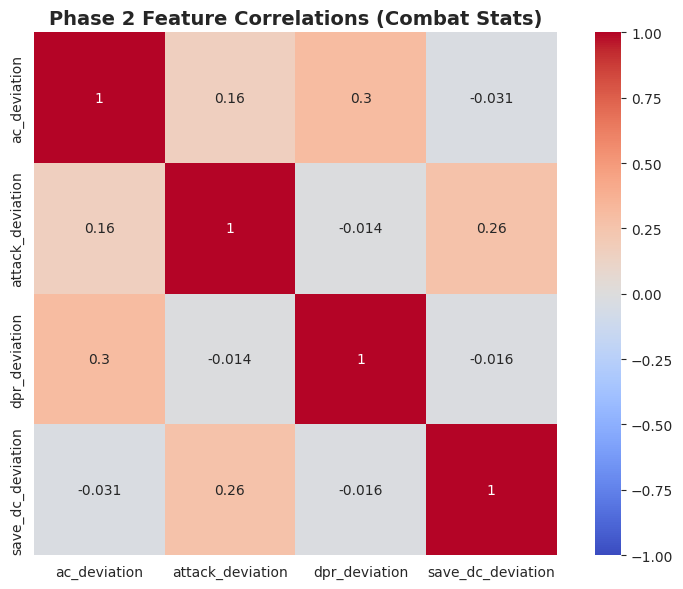


Phase 2 Correlation Matrix:
                   ac_deviation  attack_deviation  dpr_deviation  \
ac_deviation           1.000000          0.158204       0.304944   
attack_deviation       0.158204          1.000000      -0.013665   
dpr_deviation          0.304944         -0.013665       1.000000   
save_dc_deviation     -0.031118          0.264993      -0.016047   

                   save_dc_deviation  
ac_deviation               -0.031118  
attack_deviation            0.264993  
dpr_deviation              -0.016047  
save_dc_deviation           1.000000  


In [6]:
# Correlation matrix for Phase 2 features
phase2_corr = df[phase2_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(phase2_corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
plt.title('Phase 2 Feature Correlations (Combat Stats)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPhase 2 Correlation Matrix:")
print(phase2_corr)

## 4. Phase 3 Internal Correlations

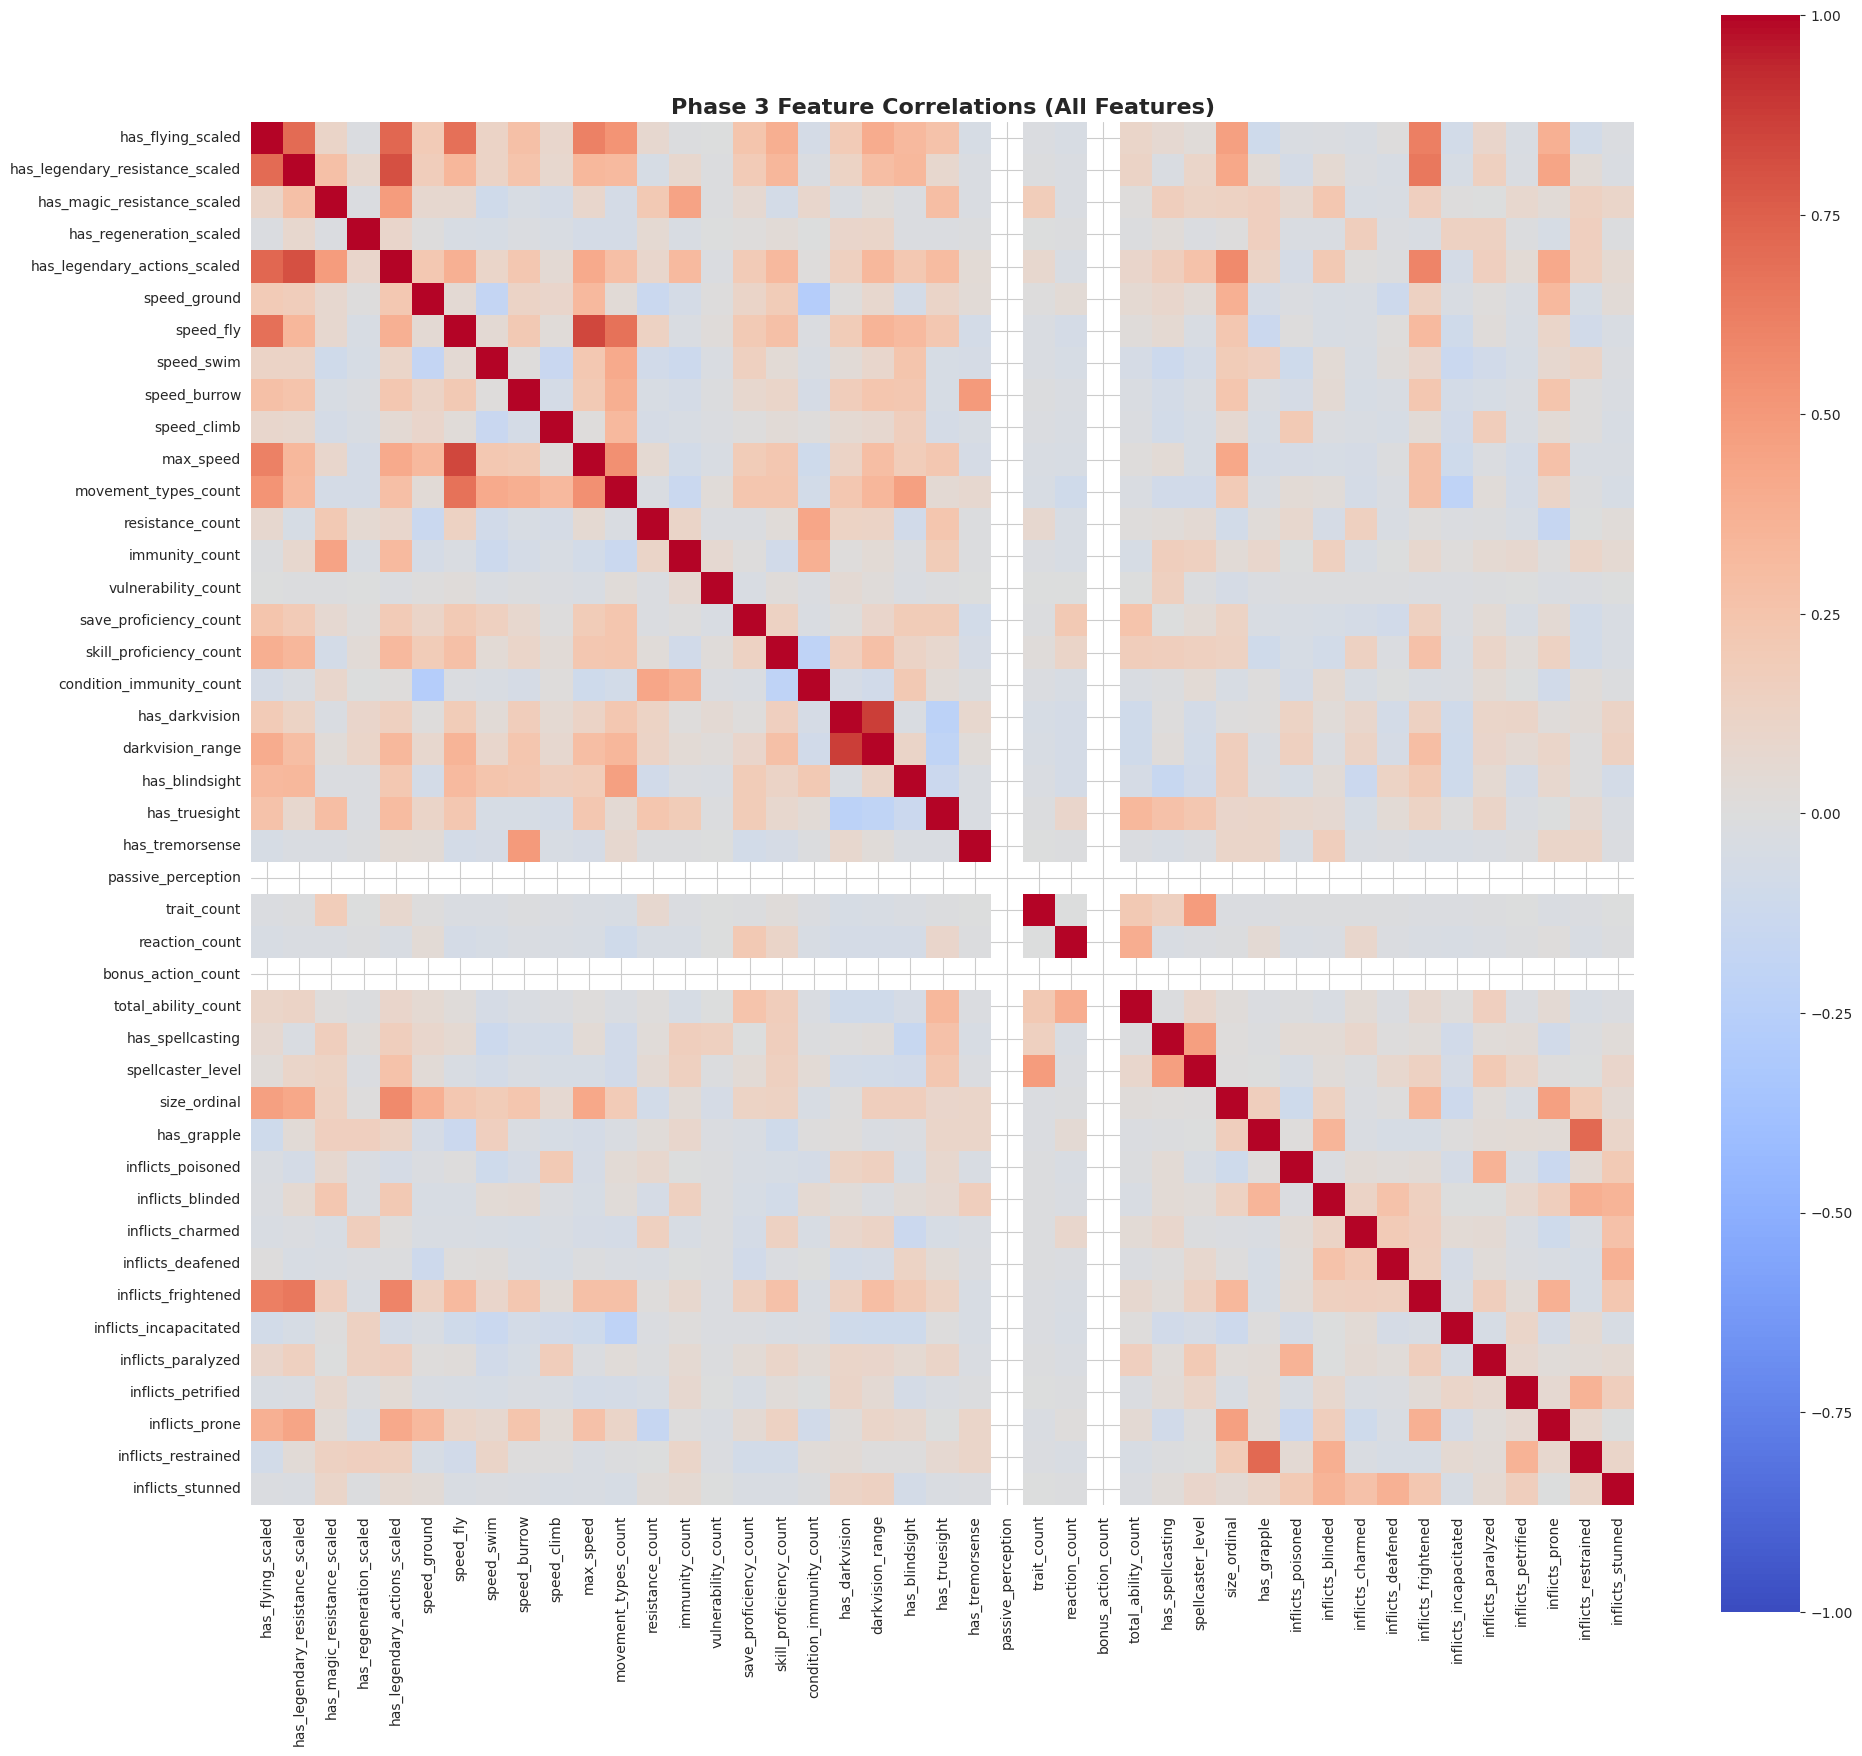


High Correlation Pairs in Phase 3 (|r| > 0.7):
                       feature1                        feature2  correlation
                 has_darkvision                darkvision_range     0.874312
                      speed_fly                       max_speed     0.840575
has_legendary_resistance_scaled    has_legendary_actions_scaled     0.810357
              has_flying_scaled    has_legendary_actions_scaled     0.721287
                    has_grapple             inflicts_restrained     0.716921
              has_flying_scaled has_legendary_resistance_scaled     0.705930


In [7]:
# Correlation matrix for Phase 3 features
phase3_corr = df[phase3_features].corr()

plt.figure(figsize=(20, 18))
sns.heatmap(phase3_corr, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
plt.title('Phase 3 Feature Correlations (All Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Find high correlation pairs in Phase 3
print("\nHigh Correlation Pairs in Phase 3 (|r| > 0.7):")
high_corr_pairs = []
for i in range(len(phase3_features)):
    for j in range(i+1, len(phase3_features)):
        corr_val = phase3_corr.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append({
                'feature1': phase3_features[i],
                'feature2': phase3_features[j],
                'correlation': corr_val
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False, key=abs)
print(high_corr_df.to_string(index=False))

## 5. Cross-Correlations: Phase 2 vs Phase 3

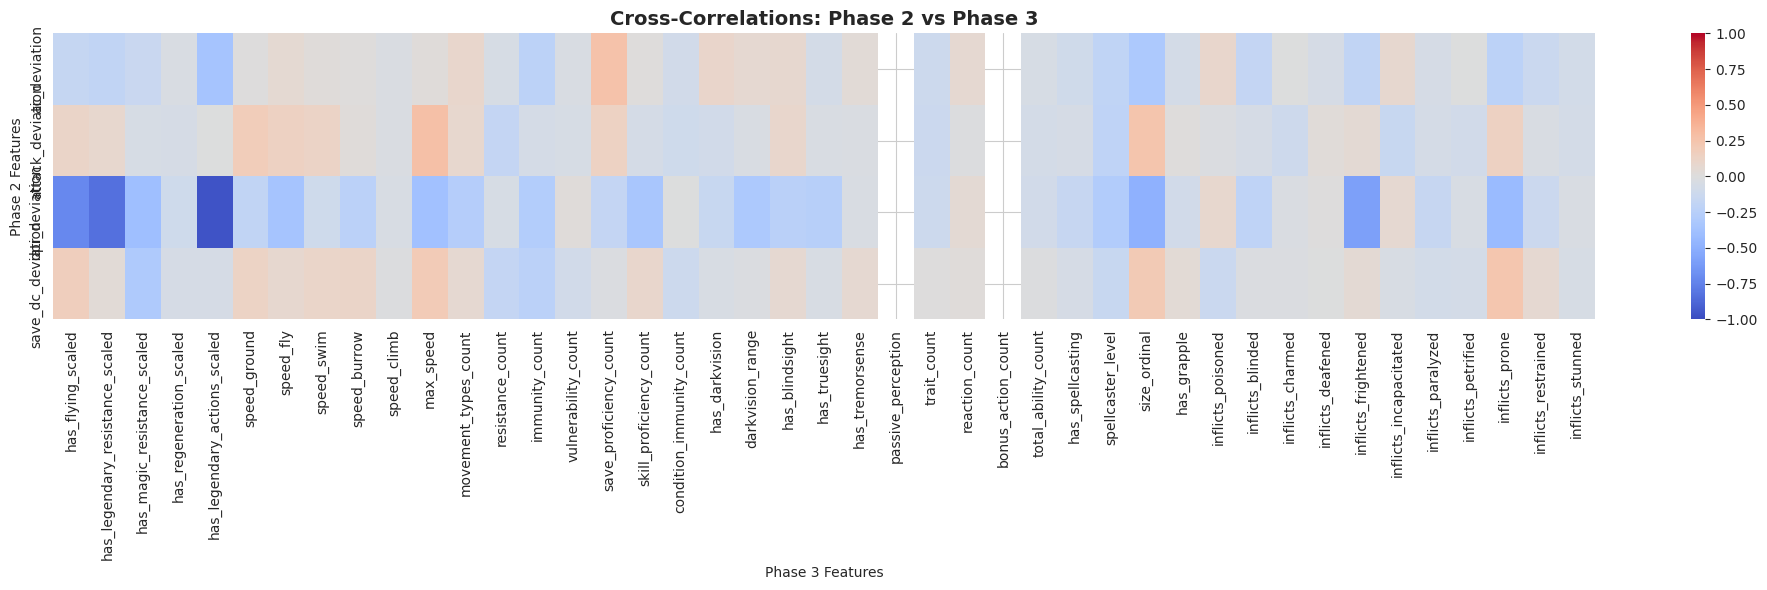


High Cross-Correlations (|r| > 0.5):
phase2_feature                  phase3_feature  correlation
 dpr_deviation    has_legendary_actions_scaled    -0.962104
 dpr_deviation has_legendary_resistance_scaled    -0.831235
 dpr_deviation               has_flying_scaled    -0.713915
 dpr_deviation             inflicts_frightened    -0.593532


In [8]:
# Cross-correlation matrix
cross_corr = df[phase2_features + phase3_features].corr().loc[phase2_features, phase3_features]

plt.figure(figsize=(20, 6))
sns.heatmap(cross_corr, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Cross-Correlations: Phase 2 vs Phase 3', fontsize=14, fontweight='bold')
plt.ylabel('Phase 2 Features')
plt.xlabel('Phase 3 Features')
plt.tight_layout()
plt.show()

# Find high cross-correlations
print("\nHigh Cross-Correlations (|r| > 0.5):")
cross_high = []
for phase2_feat in phase2_features:
    for phase3_feat in phase3_features:
        corr_val = cross_corr.loc[phase2_feat, phase3_feat]
        if abs(corr_val) > 0.5:
            cross_high.append({
                'phase2_feature': phase2_feat,
                'phase3_feature': phase3_feat,
                'correlation': corr_val
            })

cross_high_df = pd.DataFrame(cross_high).sort_values('correlation', ascending=False, key=abs)
print(cross_high_df.to_string(index=False))

## 6. VIF Analysis for Multicollinearity

In [9]:
# Calculate VIF for all features
all_features = phase2_features + phase3_features
X = df[all_features].fillna(0)  # Fill NaN with 0 for VIF calculation

vif_data = []
for i, feature in enumerate(all_features):
    vif = variance_inflation_factor(X.values, i)
    vif_data.append({
        'feature': feature,
        'VIF': vif,
        'phase': 'Phase 2' if feature in phase2_features else 'Phase 3'
    })

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print("\nVariance Inflation Factor (VIF) Scores:")
print("(VIF > 10 indicates severe multicollinearity)\n")
print(vif_df.to_string(index=False))

# Highlight features with VIF > 10
high_vif = vif_df[vif_df['VIF'] > 10]
print(f"\n\n⚠️  Features with VIF > 10 (severe multicollinearity): {len(high_vif)}")
if len(high_vif) > 0:
    print(high_vif.to_string(index=False))


Variance Inflation Factor (VIF) Scores:
(VIF > 10 indicates severe multicollinearity)

                        feature        VIF   phase
             passive_perception 596.249293 Phase 3
   has_legendary_actions_scaled  41.488937 Phase 3
                      speed_fly  26.320028 Phase 3
                  dpr_deviation  26.214248 Phase 2
                      max_speed  14.955959 Phase 3
           movement_types_count  10.025235 Phase 3
               darkvision_range   7.589286 Phase 3
              has_flying_scaled   6.879338 Phase 3
has_legendary_resistance_scaled   6.652337 Phase 3
                     speed_swim   6.079263 Phase 3
                 has_darkvision   5.994549 Phase 3
            inflicts_restrained   3.270246 Phase 3
                   speed_ground   3.165177 Phase 3
                   size_ordinal   3.102344 Phase 3
    has_magic_resistance_scaled   3.031722 Phase 3
                    speed_climb   2.889338 Phase 3
              spellcaster_level   2.764117 Ph

/workspaces/matrix_v0/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


## 7. Feature Correlation with Target (actual_hp)

/workspaces/matrix_v0/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/workspaces/matrix_v0/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Feature Correlations with Actual HP:
(Positive = feature increases HP, Negative = feature decreases HP)

                        feature  correlation_with_hp   phase
   has_legendary_actions_scaled             0.925323 Phase 3
                  dpr_deviation            -0.857900 Phase 2
              has_flying_scaled             0.744058 Phase 3
has_legendary_resistance_scaled             0.738115 Phase 3
                   size_ordinal             0.695713 Phase 3
            inflicts_frightened             0.534874 Phase 3
                      max_speed             0.481381 Phase 3
                 inflicts_prone             0.432385 Phase 3
                      speed_fly             0.420668 Phase 3
    has_magic_resistance_scaled             0.404146 Phase 3
               darkvision_range             0.372746 Phase 3
           movement_types_count             0.347128 Phase 3
        skill_proficiency_count             0.300759 Phase 3
                   ac_deviation         

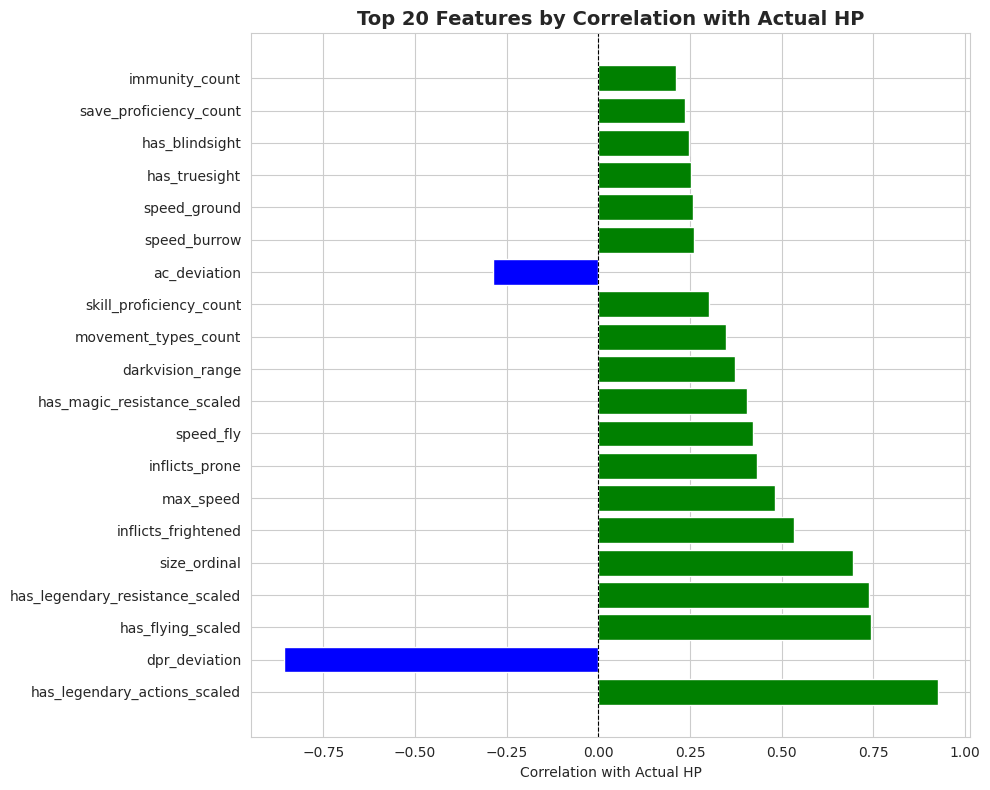

In [10]:
# Calculate correlation of each feature with actual_hp
target_corr = []
for feature in all_features:
    corr_val = df[feature].corr(df['actual_hp'])
    target_corr.append({
        'feature': feature,
        'correlation_with_hp': corr_val,
        'phase': 'Phase 2' if feature in phase2_features else 'Phase 3'
    })

target_corr_df = pd.DataFrame(target_corr).sort_values('correlation_with_hp', ascending=False, key=abs)

print("\nFeature Correlations with Actual HP:")
print("(Positive = feature increases HP, Negative = feature decreases HP)\n")
print(target_corr_df.to_string(index=False))

# Visualize top 20
top20 = target_corr_df.head(20)
plt.figure(figsize=(10, 8))
colors = ['blue' if x == 'Phase 2' else 'green' for x in top20['phase']]
plt.barh(range(len(top20)), top20['correlation_with_hp'], color=colors)
plt.yticks(range(len(top20)), top20['feature'])
plt.xlabel('Correlation with Actual HP')
plt.title('Top 20 Features by Correlation with Actual HP', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 8. Flying Investigation

### 8.1 Flying vs CR

Correlation between flying and CR: 0.331
Correlation between climb and CR: -0.002


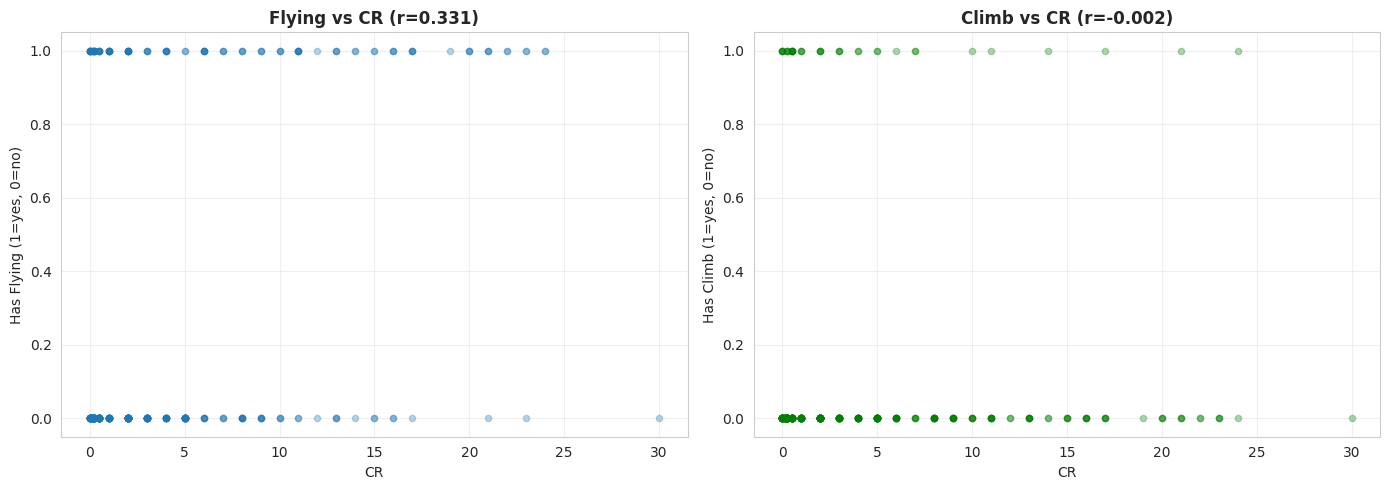

In [11]:
# Create binary flying indicator
df['has_flying'] = (df['speed_fly'] > 0).astype(int)
df['has_climb'] = (df['speed_climb'] > 0).astype(int)

# Correlation with CR
flying_cr_corr = df['has_flying'].corr(df['cr_numeric'])
climb_cr_corr = df['has_climb'].corr(df['cr_numeric'])

print(f"Correlation between flying and CR: {flying_cr_corr:.3f}")
print(f"Correlation between climb and CR: {climb_cr_corr:.3f}")

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flying
axes[0].scatter(df['cr_numeric'], df['has_flying'], alpha=0.3, s=20)
axes[0].set_xlabel('CR')
axes[0].set_ylabel('Has Flying (1=yes, 0=no)')
axes[0].set_title(f'Flying vs CR (r={flying_cr_corr:.3f})', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Climb
axes[1].scatter(df['cr_numeric'], df['has_climb'], alpha=0.3, s=20, color='green')
axes[1].set_xlabel('CR')
axes[1].set_ylabel('Has Climb (1=yes, 0=no)')
axes[1].set_title(f'Climb vs CR (r={climb_cr_corr:.3f})', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.2 Flying by CR Bins


Flying and Climb Proportions by CR Bin:
        flying_count  total_count  flying_proportion  climb_count  \
cr_bin                                                              
0-1               29          132           0.219697           14   
1-5               21          120           0.175000           11   
5-10              18           41           0.439024            4   
10-20             25           37           0.675676            3   
20+                9           12           0.750000            2   

        climb_proportion  
cr_bin                    
0-1             0.106061  
1-5             0.091667  
5-10            0.097561  
10-20           0.081081  
20+             0.166667  


/tmp/ipykernel_3202/349960343.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flying_by_cr = df.groupby('cr_bin').agg({


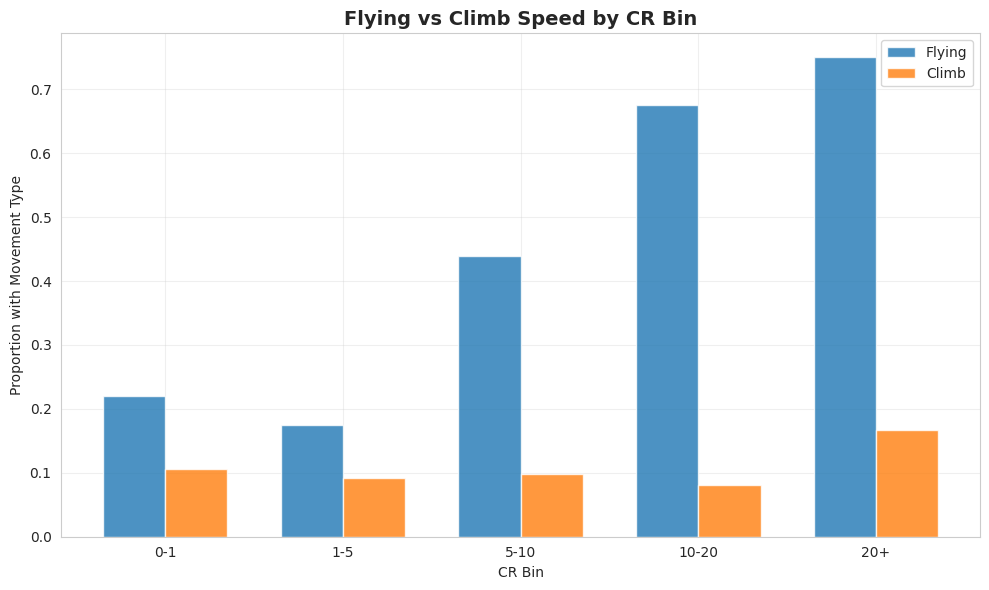

In [12]:
# Create CR bins
df['cr_bin'] = pd.cut(df['cr_numeric'], bins=[0, 1, 5, 10, 20, 35], labels=['0-1', '1-5', '5-10', '10-20', '20+'])

# Calculate proportions
flying_by_cr = df.groupby('cr_bin').agg({
    'has_flying': ['sum', 'count', 'mean'],
    'has_climb': ['sum', 'mean']
})

flying_by_cr.columns = ['flying_count', 'total_count', 'flying_proportion', 'climb_count', 'climb_proportion']
print("\nFlying and Climb Proportions by CR Bin:")
print(flying_by_cr)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(flying_by_cr))
width = 0.35
ax.bar([i - width/2 for i in x], flying_by_cr['flying_proportion'], width, label='Flying', alpha=0.8)
ax.bar([i + width/2 for i in x], flying_by_cr['climb_proportion'], width, label='Climb', alpha=0.8)
ax.set_xlabel('CR Bin')
ax.set_ylabel('Proportion with Movement Type')
ax.set_title('Flying vs Climb Speed by CR Bin', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(flying_by_cr.index)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.3 Flying by Creature Type


Flying Proportion by Creature Type:
                                flying_count  total_count  flying_proportion  \
Type                                                                           
Celestial                                  4            4              1.000   
Fiend (Shapechanger)                       2            2              1.000   
Undead                                     1            1              1.000   
fiend (devil, shapechanger)                1            1              1.000   
fiend (shapechanger)                       1            1              1.000   
dragon                                    42           43              0.977   
celestial                                  5            6              0.833   
elemental                                  9           16              0.562   
fiend (devil)                              4            9              0.444   
fiend (demon)                              3            8              0.375   
Dra

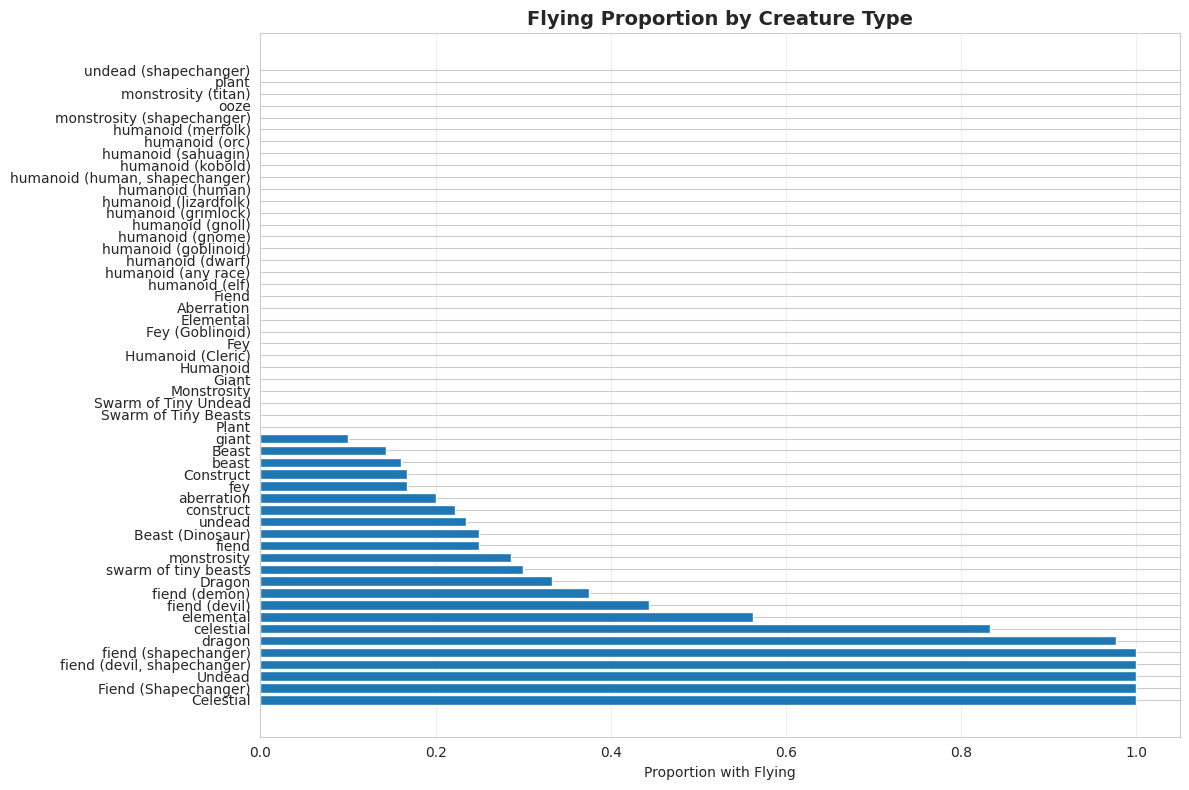


Flying proportion for beasts: 0.160
Flying proportion for non-beasts: 0.340


In [13]:
# Check if creature type exists in dataset
if 'Type' in df.columns:
    # Flying by creature type
    flying_by_type = df.groupby('Type').agg({
        'has_flying': ['sum', 'count', 'mean'],
        'cr_numeric': 'mean'
    }).round(3)
    
    flying_by_type.columns = ['flying_count', 'total_count', 'flying_proportion', 'avg_cr']
    flying_by_type = flying_by_type.sort_values('flying_proportion', ascending=False)
    
    print("\nFlying Proportion by Creature Type:")
    print(flying_by_type)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(range(len(flying_by_type)), flying_by_type['flying_proportion'])
    ax.set_yticks(range(len(flying_by_type)))
    ax.set_yticklabels(flying_by_type.index)
    ax.set_xlabel('Proportion with Flying')
    ax.set_title('Flying Proportion by Creature Type', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    # Beast vs non-beast
    df['is_beast'] = (df['Type'].str.lower() == 'beast').astype(int)
    beast_flying = df.groupby('is_beast')['has_flying'].mean()
    print(f"\nFlying proportion for beasts: {beast_flying.get(1, 0):.3f}")
    print(f"Flying proportion for non-beasts: {beast_flying.get(0, 0):.3f}")
else:
    print("⚠️  'Type' column not found in dataset. Cannot analyze by creature type.")

### 8.4 Flying Correlation with Combat Stats


Flying Correlation with Combat Stats:
      combat_stat  correlation_with_flying
    dpr_deviation                -0.274743
     ac_deviation                 0.094246
 attack_deviation                 0.090409
save_dc_deviation                -0.028070


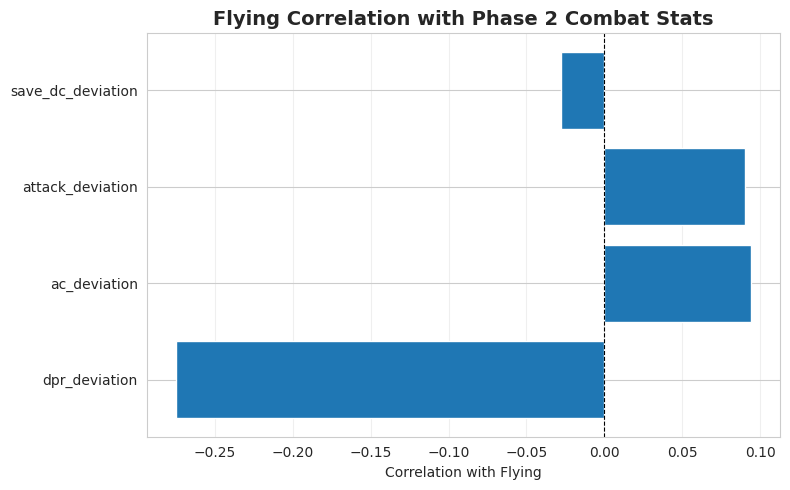

In [14]:
# Correlations between flying and Phase 2 features
flying_combat_corr = []
for feature in phase2_features:
    corr_val = df['has_flying'].corr(df[feature])
    flying_combat_corr.append({
        'combat_stat': feature,
        'correlation_with_flying': corr_val
    })

flying_combat_df = pd.DataFrame(flying_combat_corr).sort_values('correlation_with_flying', ascending=False, key=abs)
print("\nFlying Correlation with Combat Stats:")
print(flying_combat_df.to_string(index=False))

# Visualize
plt.figure(figsize=(8, 5))
plt.barh(range(len(flying_combat_df)), flying_combat_df['correlation_with_flying'])
plt.yticks(range(len(flying_combat_df)), flying_combat_df['combat_stat'])
plt.xlabel('Correlation with Flying')
plt.title('Flying Correlation with Phase 2 Combat Stats', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 8.5 Flying HP Impact Analysis

In [16]:
df['cr_bin'].value_counts()

cr_bin
0-1      132
1-5      120
5-10      41
10-20     37
20+       12
Name: count, dtype: int64

In [ ]:
# Analyze actual HP impact of flying
# Compare creatures with/without flying at similar CR

from scipy.stats import ttest_ind

# For each CR bin, compare HP of flyers vs non-flyers
flying_hp_impact = []
for cr_bin in df['cr_bin'].unique():
    if pd.isna(cr_bin):
        continue
    
    bin_data = df[df['cr_bin'] == cr_bin]
    flyers = bin_data[bin_data['has_flying'] == 1]['actual_hp']
    non_flyers = bin_data[bin_data['has_flying'] == 0]['actual_hp']
    
    if len(flyers) > 0 and len(non_flyers) > 0:
        t_stat, p_value = ttest_ind(flyers, non_flyers)
        flying_hp_impact.append({
            'cr_bin': cr_bin,
            'flyers_mean_hp': flyers.mean(),
            'non_flyers_mean_hp': non_flyers.mean(),
            'hp_difference': flyers.mean() - non_flyers.mean(),
            'flyers_count': len(flyers),
            'non_flyers_count': len(non_flyers),
            'p_value': p_value
        })

flying_hp_df = pd.DataFrame(flying_hp_impact)
print("\nHP Impact of Flying by CR Bin:")
print("(Positive hp_difference = flyers have MORE HP)\n")
print(flying_hp_df.to_string(index=False))

# Overall flying vs non-flying HP comparison
all_flyers_hp = df[df['has_flying'] == 1]['actual_hp']
all_non_flyers_hp = df[df['has_flying'] == 0]['actual_hp']
overall_t, overall_p = ttest_ind(all_flyers_hp, all_non_flyers_hp)

print(f"\n\nOverall Comparison:")
print(f"Flyers mean HP: {all_flyers_hp.mean():.1f} (n={len(all_flyers_hp)})")
print(f"Non-flyers mean HP: {all_non_flyers_hp.mean():.1f} (n={len(all_non_flyers_hp)})")
print(f"Difference: {all_flyers_hp.mean() - all_non_flyers_hp.mean():.1f} HP")
print(f"T-test p-value: {overall_p:.4f}")
print(f"Statistically significant: {'Yes' if overall_p < 0.05 else 'No'}")


HP Impact of Flying by CR Bin:
(Positive hp_difference = flyers have MORE HP)

cr_bin  flyers_mean_hp  non_flyers_mean_hp  hp_difference  flyers_count  non_flyers_count  p_value
   0-1       17.862069           18.203883      -0.341815            29               103 0.861918
   1-5       56.761905           68.141414     -11.379509            21                99 0.070601
  5-10      130.055556          129.347826       0.707729            18                23 0.945992
 10-20      214.800000          184.166667      30.633333            25                12 0.130298
   20+      427.666667          427.666667       0.000000             9                 3 1.000000


Overall Comparison:
Flyers mean HP: 118.5 (n=113)
Non-flyers mean HP: 56.8 (n=269)
Difference: 61.8 HP
T-test p-value: 0.0000
Statistically significant: Yes


## 9. Recommendations

### 9.1 Features to Remove (High Multicollinearity)

In [ ]:
print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

print("\n1. FEATURES WITH SEVERE MULTICOLLINEARITY (VIF > 10):")
if len(high_vif) > 0:
    print("\nConsider removing or combining these features:")
    for idx, row in high_vif.iterrows():
        print(f"   - {row['feature']} (VIF={row['VIF']:.1f})")
else:
    print("   ✓ No features with VIF > 10")

print("\n2. HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7):")
if len(high_corr_df) > 0:
    print("\nConsider removing one feature from each pair:")
    for idx, row in high_corr_df.iterrows():
        print(f"   - {row['feature1']} ↔ {row['feature2']} (r={row['correlation']:.3f})")
else:
    print("   ✓ No feature pairs with |r| > 0.7")


RECOMMENDATIONS

1. FEATURES WITH SEVERE MULTICOLLINEARITY (VIF > 10):

Consider removing or combining these features:
   - passive_perception (VIF=596.2)
   - has_legendary_actions_scaled (VIF=41.5)
   - speed_fly (VIF=26.3)
   - dpr_deviation (VIF=26.2)
   - max_speed (VIF=15.0)
   - movement_types_count (VIF=10.0)

2. HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7):

Consider removing one feature from each pair:
   - has_darkvision ↔ darkvision_range (r=0.874)
   - speed_fly ↔ max_speed (r=0.841)
   - has_legendary_resistance_scaled ↔ has_legendary_actions_scaled (r=0.810)
   - has_flying_scaled ↔ has_legendary_actions_scaled (r=0.721)
   - has_grapple ↔ inflicts_restrained (r=0.717)
   - has_flying_scaled ↔ has_legendary_resistance_scaled (r=0.706)


### 9.2 Flying: Should it Move to Phase 2?

In [ ]:
print("\n3. FLYING AS PHASE 2 FIXED PENALTY:")
print(f"\n   Correlation with CR: {flying_cr_corr:.3f}")
print(f"   Mean HP difference (flyers vs non-flyers): {all_flyers_hp.mean() - all_non_flyers_hp.mean():.1f} HP")
print(f"   Statistical significance: p={overall_p:.4f}")

if flying_cr_corr > 0.3:
    print("\n   ✓ RECOMMENDATION: Move flying to Phase 2 as fixed penalty")
    print("     - Flying shows moderate positive correlation with CR")
    print("     - This makes it conceptually similar to other fixed combat advantages")
elif flying_cr_corr < -0.3:
    print("\n   ✗ RECOMMENDATION: Keep flying in Phase 3 as scaled feature")
    print("     - Flying shows negative correlation with CR")
    print("     - Scaled approach is more appropriate")
else:
    print("\n   ~ RECOMMENDATION: Either approach could work")
    print("     - Flying shows weak correlation with CR")
    print("     - Decision should be based on conceptual grounds")

# Estimate flying penalty coefficient
if overall_p < 0.05:
    avg_baseline_hp = df['hp_baseline'].mean()
    estimated_penalty = (all_flyers_hp.mean() - all_non_flyers_hp.mean()) / avg_baseline_hp
    print(f"\n   Estimated flying penalty coefficient: {estimated_penalty:.2f} HP per baseline HP")
    print(f"   (For a creature with 100 baseline HP, flying adds ~{estimated_penalty * 100:.0f} HP)")


3. FLYING AS PHASE 2 FIXED PENALTY:

   Correlation with CR: 0.331
   Mean HP difference (flyers vs non-flyers): 61.8 HP
   Statistical significance: p=0.0000

   ✓ RECOMMENDATION: Move flying to Phase 2 as fixed penalty
     - Flying shows moderate positive correlation with CR
     - This makes it conceptually similar to other fixed combat advantages

   Estimated flying penalty coefficient: 0.68 HP per baseline HP
   (For a creature with 100 baseline HP, flying adds ~68 HP)


### 9.3 Phase 3 Positive Coefficients

In [ ]:
print("\n4. PHASE 3 FEATURES WITH POSITIVE HP CORRELATION:")
print("\n   (These features increase HP, which may indicate confounding)\n")

positive_phase3 = target_corr_df[
    (target_corr_df['phase'] == 'Phase 3') & 
    (target_corr_df['correlation_with_hp'] > 0)
].sort_values('correlation_with_hp', ascending=False)

if len(positive_phase3) > 0:
    print(f"   Found {len(positive_phase3)} Phase 3 features with positive correlation:\n")
    for idx, row in positive_phase3.head(10).iterrows():
        print(f"   - {row['feature']}: r={row['correlation_with_hp']:.3f}")
    
    if len(positive_phase3) > 10:
        print(f"\n   ... and {len(positive_phase3) - 10} more")
    
    print("\n   ⚠️  These features may be:")
    print("     - Correlated with CR (higher CR creatures have more of these)")
    print("     - Correlated with Phase 2 combat stats")
    print("     - Proxies for other unmeasured factors")
else:
    print("   ✓ No Phase 3 features with positive correlation")


4. PHASE 3 FEATURES WITH POSITIVE HP CORRELATION:

   (These features increase HP, which may indicate confounding)

   Found 34 Phase 3 features with positive correlation:

   - has_legendary_actions_scaled: r=0.925
   - has_flying_scaled: r=0.744
   - has_legendary_resistance_scaled: r=0.738
   - size_ordinal: r=0.696
   - inflicts_frightened: r=0.535
   - max_speed: r=0.481
   - inflicts_prone: r=0.432
   - speed_fly: r=0.421
   - has_magic_resistance_scaled: r=0.404
   - darkvision_range: r=0.373

   ... and 24 more

   ⚠️  These features may be:
     - Correlated with CR (higher CR creatures have more of these)
     - Correlated with Phase 2 combat stats
     - Proxies for other unmeasured factors


### 9.4 Summary

In [ ]:
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print("\nKey Findings:")
print(f"1. {len(high_vif)} features have VIF > 10 (severe multicollinearity)")
print(f"2. {len(high_corr_df)} feature pairs have |r| > 0.7 (high correlation)")
print(f"3. {len(cross_high_df)} cross-correlations between Phase 2 and Phase 3 exceed |r| > 0.5")
print(f"4. {len(positive_phase3)} Phase 3 features show positive correlation with HP")
print(f"5. Flying-CR correlation: {flying_cr_corr:.3f}")

print("\nNext Steps:")
print("1. Review features with high VIF and remove redundant ones")
print("2. Consider feature engineering to combine correlated features")
print("3. Move flying to Phase 2 (if correlation analysis supports it)")
print("4. Implement Phase 1.5 for resistances/immunities")
print("5. Parse legendary actions into DPR and condition counts")
print("6. Retrain model and verify Phase 3 coefficients are more sensible")

print("\n" + "="*80)


SUMMARY

Key Findings:
1. 6 features have VIF > 10 (severe multicollinearity)
2. 6 feature pairs have |r| > 0.7 (high correlation)
3. 4 cross-correlations between Phase 2 and Phase 3 exceed |r| > 0.5
4. 34 Phase 3 features show positive correlation with HP
5. Flying-CR correlation: 0.331

Next Steps:
1. Review features with high VIF and remove redundant ones
2. Consider feature engineering to combine correlated features
3. Move flying to Phase 2 (if correlation analysis supports it)
4. Implement Phase 1.5 for resistances/immunities
5. Parse legendary actions into DPR and condition counts
6. Retrain model and verify Phase 3 coefficients are more sensible

